In [1]:
from moabb.datasets import *
from moabb.paradigms import P300
import tensorly as tl

dataset = BNCI2014_008()
paradigm = P300(resample=32)
X, y, meta = paradigm.get_data(dataset, subjects=[1])
X = tl.tensor(X)
X.shape

(4200, 8, 32)

In [2]:
from bttda.hoda import BTTDA

bttda = BTTDA(
    ranks=[None]*8,
    hoda_params=dict(
        rank=None,
        shrinkage='lw',
        obj='tr',
        verbose=True,
        theta=0.2,
        toeplitz=(1,),       
    ),
    verbose=True,
    extra_train_info=True,

)
bttda.fit(X,y)

Fitting block 1/8...


Forward model :  22%|██▏       | 55/255 [00:00<00:01, 187.53it/s]


Fitting block 2/8...


Forward model :   5%|▍         | 12/255 [00:00<00:01, 229.43it/s]


Fitting block 3/8...


...

Fitting block 7/8...


Forward model :   5%|▍         | 12/255 [00:00<00:00, 252.54it/s]


Fitting block 8/8...


Forward model :   5%|▌         | 14/255 [00:00<00:00, 245.25it/s]


BTTDA(extra_train_info=True,
      hoda_params={'obj': 'tr', 'rank': None, 'shrinkage': 'lw', 'theta': 0.2,
                   'toeplitz': (1,), 'verbose': True},
      ranks=[None, None, None, None, None, None, None, None], verbose=True)

In [3]:
import pandas as pd

df = pd.DataFrame(bttda.train_info_)
df

,block,rank,F_tr,F_rt,mse,nmse
0,1,"(1, 4)",0.215956,0.000171,78.965012,0.997191
1,2,"(1, 4)",0.201874,0.000174,78.685920,0.993666
2,3,"(1, 4)",0.174636,0.000178,78.219396,0.987775
3,4,"(1, 4)",0.152210,0.000218,77.860314,0.983240
4,5,"(1, 4)",0.126993,0.000233,77.299244,0.976155
5,6,"(1, 4)",0.119563,0.000234,77.073406,0.973303
6,7,"(1, 4)",0.111643,0.000239,76.906431,0.971194
7,8,"(1, 4)",0.106598,0.000239,76.786173,0.969676


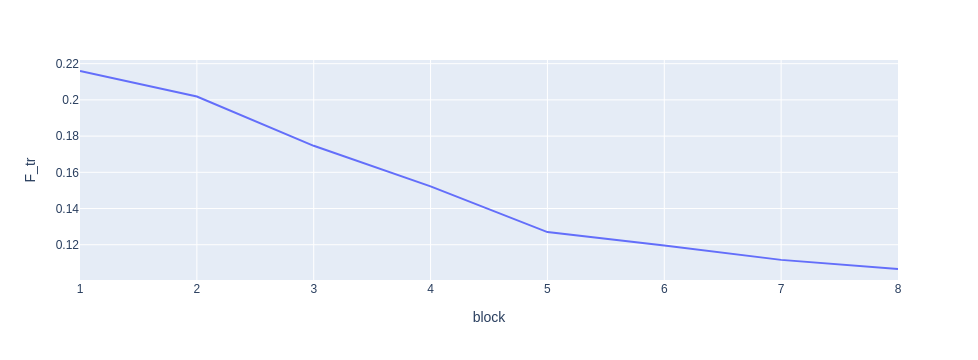

In [4]:
import plotly.express as px

if bttda.extra_train_info:
    fig = px.line(df, x='block', y='F_tr')
    fig.show()


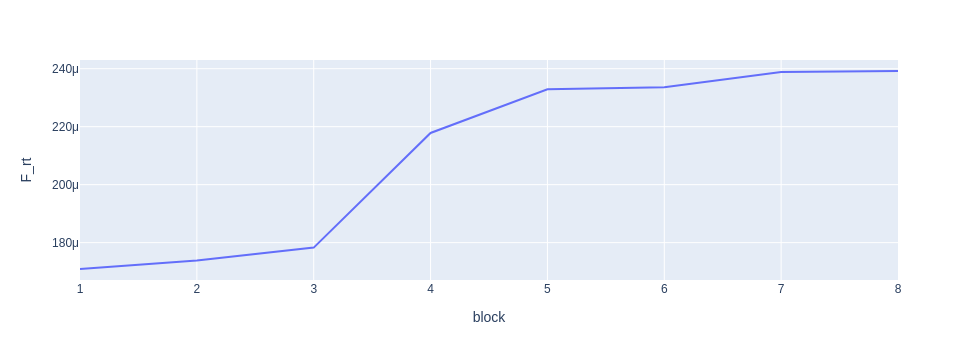

In [5]:
if bttda.extra_train_info:
    fig = px.line(df, x='block', y='F_rt')
    fig.show()


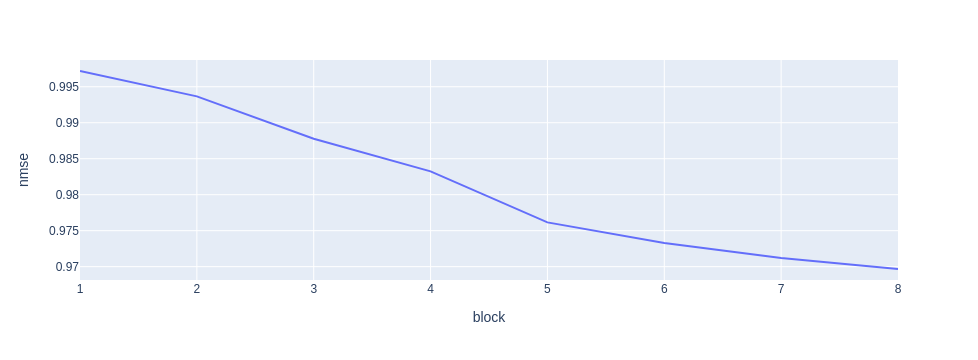

In [6]:
if bttda.extra_train_info:
    fig = px.line(df, x='block', y='nmse')
    fig.show()


In [7]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from bttda.classification import SelectFCutoff

Xt = bttda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))

select = SelectFCutoff()
xts = select.fit_transform(xt,y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': select.scores_,
    'significant': select.scores_>1,
})
df

,feature,F,significant
0,0,793.280356,True
1,1,0.000002,False
2,2,69.339127,True
3,3,1.157183,True
4,4,754.177968,True
5,5,0.015410,False
6,6,50.761395,True
7,7,2.361831,True
8,8,242.362785,True
9,9,6.548343,True


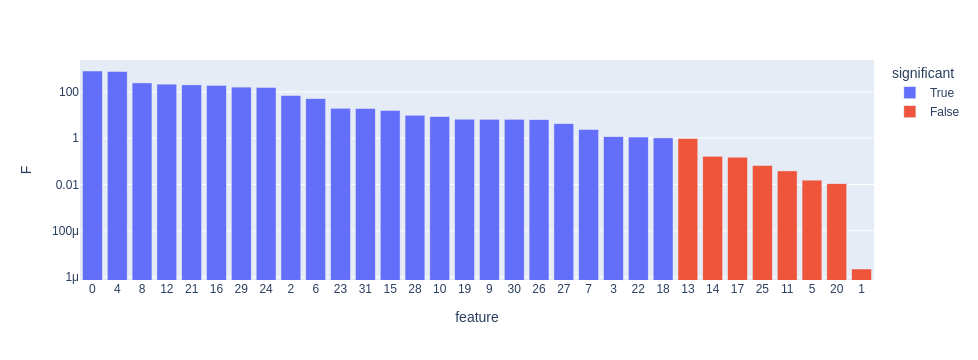

In [8]:
fig = px.bar(df, x='feature', y='F', color='significant', log_y=True)
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

In [9]:
from sklearn.decomposition import PCA

x_viz = PCA(n_components=2, whiten=True).fit_transform(xts)
fig = px.scatter(x=x_viz[:,0], y=x_viz[:,1], color=y)
fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
  )

In [10]:
from bttda.hoda import f_multiway

print(f"trace-ratio: {f_multiway(xts,y, method='tr')}")
print(f"ratio-trace: {f_multiway(xts,y, method='rt')}")

trace-ratio: 0.1383537139884
ratio-trace: 0.00023687419838648455
